<center> <h1> SSL on Graphs for Protein Stability Prediction </h1> </center>
<hr>

<center> <h3> Participant Project @ Petnice Summer Institute, Summer School On Scientific Machine Learning, August 2026 </h3> </center>
<center> Authored by <b>Luka Nedimović</b> and <b>Miron Petrik Popović</b> </center>

<center>
<a href="https://colab.research.google.com/github/zenwor/sciml26_gjepa/blob/main/notebooks/sciml_graph_jepa.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
</center>

Mutating a single amino acid can make a protein fall apart, or make it tougher. That number
is **ΔΔG** (delta-delta-G). Measuring it in the lab is slow and expensive, so we have labels for a vanishing
fraction of possible mutations. Protein **structures**, meanwhile, are abundant and free.

Throughout history, many approaches have been explored to try and solve this labeling cost problem. One of the possible answers to this question is **self-supervised learning**.

Over the next several days, you will build a model that learns from protein structures with *no
labels at all*, then ask whether that helped it predict stability. However counterintuitive it may sound, it is indeed possible!

### Roadmap

| | | |
|---|---|---|
| **Part 1** | 🕸 What is a graph? | and why neural networks find them awkward |
| **Part 2** | 🧠 Graph neural networks | you will build one from scratch |
| **Part 3** | 🧬 Proteins as graphs | the biology you actually need |
| **Part 4** | 🎭 Self-supervised learning | learning without labels, and how it fails |
| **Part 5** | 🔮 JEPA | predict the representation, not the thing |
| **Part 6** | 🕸🎭 SSL on graphs | what can you even hide? |
| **Part 7** | 🛠 Build the model | your encoder, your objective |
| **Part 8** | 📊 Pretrain, fine-tune, benchmark | the whole pipeline |
| **Part 9** | 🔬 Go find something out | the actual project |

### The numbers you are aiming at

ThermoMPNN (PNAS 2024) used this exact dataset and split:

| | Spearman |
|---|---|
| their model, from scratch | **0.642** |
| their model, with pretrained weights | **0.725** |

You will not beat 0.725. That model is pretrained on the entire Protein Data Bank. The
question is how far a small model *you* train gets, and whether pretraining helps.

### How to read this notebook

Sections are marked so you know what is expected of you:

| | |
|---|---|
| 📖 | **Read it.** Concepts, with as little hand-waving as we could manage. |
| 🔍 | **Run it.** A demo. Read the code, predict the output, then run and see if you were right. |
| 🛠 | **Write it.** Your turn. There is a `TODO` and a function that raises until you fill it in. |
| ✅ | **Check it.** Call the checker. It tests properties, not just shapes, and gives hints when something is wrong. |
| 🔬 | **Break it.** Open-ended. No checker, no right answer, just questions worth chasing. |
| ⚠ | **A trap.** Something that will silently cost you a day if you do not know about it. |

The checkers live in `gjepa/checks.py`. Go and read them whenever you like. Knowing what
you are being tested on is half of knowing what to build.

One habit worth forming right now: **before you run a demo cell, guess what it will print.**
You will learn roughly ten times more from the cells where you guessed wrong.

### Setting up

**On Google Colab:** run the cell below first. It clones the project and installs what is
missing. Colab already ships a working CUDA build of PyTorch, so we deliberately do not
touch torch: installing another one on top is the usual way to break a Colab runtime. You
will need to re-run this cell after every disconnect.

**On your own machine:** do not run it. Run `./setup.sh` once in a terminal, then pick the
`Python (sciml-gjepa)` kernel with Kernel > Change kernel.

In [ ]:
import os, subprocess, sys

REPO = "https://github.com/zenwor/sciml26_gjepa.git"

if "google.colab" in sys.modules:
    # Safe to re-run. "am I already inside the repo?" is the test, not "does a folder called
    # sciml26_gjepa exist here?", otherwise a second run clones the repo into itself.
    if not os.path.isdir("gjepa"):
        if not os.path.isdir("sciml26_gjepa"):
            subprocess.run(["git", "clone", "-q", REPO], check=True)
        os.chdir("sciml26_gjepa")

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
                   check=True)
    print("Colab setup done. Working directory:", os.getcwd())
else:
    print("Not on Colab, nothing to do here. Run ./setup.sh once in a terminal instead.")

: 

In [1]:
import sys, os
from loguru import logger

# loguru writes to stderr by default, which Jupyter paints red so every line looks
# like an error. Send it to stdout with a compact format instead.
logger.remove()
logger.add(sys.stdout, colorize=True, level="DEBUG",
           format="<level>{level: <7}</level> | <level>{message}</level>")

try:
    import torch
except ModuleNotFoundError:
    raise RuntimeError(
        "\n\n  WRONG KERNEL.\n"
        f"  This notebook is running:  {sys.executable}\n"
        "  which does not have torch installed.\n\n"
        "  Fix: Kernel > Change kernel > 'Python (sciml-gjepa)'\n\n"
        "  If that kernel is not in the list, run this once from the project root:\n"
        "      .venv/bin/python -m ipykernel install --user \\\n"
        "          --name sciml-gjepa --display-name 'Python (sciml-gjepa)'\n"
    ) from None

import torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt

# make `import gjepa` work whether you launched Jupyter from the project root or notebooks/
_here = os.getcwd()
_root = _here if os.path.isdir(os.path.join(_here, "gjepa")) else os.path.dirname(_here)
sys.path.insert(0, _root)

torch.manual_seed(0)

logger.info(f"python  {sys.executable}")
logger.info(f"project {_root}")
logger.info(f"torch   {torch.__version__}  (built against CUDA {torch.version.cuda})")

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    cc = torch.cuda.get_device_capability(0)
    logger.success(f"GPU     {props.name}, {props.total_memory / 1e9:.0f} GB, "
                   f"compute capability {cc[0]}.{cc[1]}")
    if cc[0] < 8:
        logger.info("        (Turing or older: fp32 only in this notebook, which is what we use)")
else:
    logger.warning("NO GPU VISIBLE. Everything will still run, but pretraining goes from")
    logger.warning("about 25 minutes to several hours.")
    logger.warning("On Colab: Runtime > Change runtime type > T4 GPU, then re-run this cell.")

# num_workers=0 is the safe default everywhere. On WSL2 it is mandatory: DataLoader workers
# forked from a CUDA process corrupt GPU memory accounting and cause phantom out-of-memory
# errors. On Colab you can raise it to 2 for a speedup.

INFO    | python  c:\Users\fidan\sciml26_gjepa\.venv\Scripts\python.exe
INFO    | project c:\Users\fidan\sciml26_gjepa
INFO    | torch   2.11.0+cu128  (built against CUDA 12.8)
WARNING | NO GPU VISIBLE. Everything will still run, but pretraining goes from
WARNING | about 25 minutes to several hours.
WARNING | On Colab: Runtime > Change runtime type > T4 GPU, then re-run this cell.


In [2]:
import torch
import torch_geometric
import sys, os

sys.path.insert(0, os.path.abspath('..'))

print(f"Python:  {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"PyG:     {torch_geometric.__version__}")

c:\Users\fidan\sciml26_gjepa\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python:  3.10.20 (main, Aug  7 2026, 02:23:44) [MSC v.1944 64 bit (AMD64)]
PyTorch: 2.11.0+cu128
PyG:     2.8.0.post1


In [4]:
device = 'cpu'
print(f"Using device: {device}")
print("Ready to start!")

Using device: cpu
Ready to start!


---
# Part 1: 🕸 What is a graph?

## 📖 Things that are graphs

A graph is a set of **things** and a set of **connections between things**. That is the
entire definition, and it is so general that it covers most of what people care about:

* a road network: cities connected by roads
* a social network: people connected by friendships
* the internet: pages connected by links
* a molecule: atoms connected by bonds
* a protein: amino acids connected by physical contact

We call the things **nodes** (or vertices) and the connections **edges**. Both can carry
information. A node in a molecule knows which element it is. An edge knows whether it is a
single or double bond.

So far, so ordinary. The interesting part is what happens when you try to feed one of these
into a neural network.

In [2]:
import numpy as np

## 📖 Why neural networks find graphs awkward

Think about what a normal neural network expects. An image is a grid: every pixel has a
position, every image of a given size has exactly the same number of pixels in exactly the
same arrangement. A sentence is a sequence: word 1, word 2, word 3, in order. In both cases
there is a fixed, meaningful ordering that you can rely on.

A graph has neither.

**There is no natural order.** If you have five atoms, which one is "atom number 1"? The
answer is that there is no answer. You have to pick an order to store them in a computer,
but that choice is arbitrary. And here is the problem: if you flatten your graph into a
vector and feed it to an MLP, the network sees that arbitrary order as if it meant something.
Relabel the atoms and the MLP gives you a different answer for the same molecule.

**There is no fixed size.** One protein has 40 residues, another has 300. An MLP needs a
fixed-size input.

The property we want is called **permutation invariance**: relabelling the nodes must not
change the answer. For a whole-graph prediction (is this molecule toxic?) the output should
be identical. For a per-node prediction (is this residue buried?) the outputs should come back
in the same permuted order, which is called **permutation equivariance**.

Almost everything about graph neural networks follows from taking this one requirement
seriously.

## 🔍 Demo 1.1: the same graph, stored two different ways

Two common representations. The **adjacency matrix** is an `N x N` table where entry
`(i, j)` is 1 if there is an edge from `i` to `j`. The **edge list** (PyTorch Geometric calls
it `edge_index`) is a `2 x E` array listing the source and destination of every edge.

For a protein with 300 residues and 5000 contacts, the adjacency matrix has 90,000 entries
of which 5000 are non-zero. The edge list has 10,000 numbers and no waste. That is why
essentially every graph library uses edge lists.

**Guess before you run:** we build a graph, then relabel the nodes. Which representation
will look obviously different, and which will look subtly different?

In [5]:
# A tiny graph:   0 --- 1 --- 2 --- 3      and node 4 all on its own
edge_index = torch.tensor([[0, 1, 1, 2, 2, 3],      # source
                           [1, 0, 2, 1, 3, 2]])     # destination
num_nodes = 5

def to_adjacency(ei, n):
    a = torch.zeros(n, n, dtype=torch.long)
    a[ei[0], ei[1]] = 1
    return a

logger.info("edge_index (2 x E), the sparse way:")
logger.info(f"\n{edge_index}")
logger.info("adjacency matrix (N x N), the dense way:")
logger.info(f"\n{to_adjacency(edge_index, num_nodes)}")

# now relabel the nodes: old node i becomes new node perm[i]
perm = torch.tensor([3, 1, 4, 0, 2])
relabelled = perm[edge_index]

logger.info("after relabelling, the SAME graph looks like this:")
logger.info(f"\n{to_adjacency(relabelled, num_nodes)}")
logger.warning("Same graph. Completely different matrix. This is the problem.")

INFO    | edge_index (2 x E), the sparse way:
INFO    | 
tensor([[0, 1, 1, 2, 2, 3],
        [1, 0, 2, 1, 3, 2]])
INFO    | adjacency matrix (N x N), the dense way:
INFO    | 
tensor([[0, 1, 0, 0, 0],
        [1, 0, 1, 0, 0],
        [0, 1, 0, 1, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0]])
INFO    | after relabelling, the SAME graph looks like this:
INFO    | 
tensor([[0, 0, 0, 0, 1],
        [0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [1, 1, 0, 0, 0]])
WARNING | Same graph. Completely different matrix. This is the problem.


In [7]:
# MLP sees the matrix → different numbers → different answer 
# But it's the SAME protein!

In [8]:
# GNNs solve this by using message passing instead of reading node positions.

In [9]:
# edge_index[0] = [0, 1, 1, 2, 2, 3]  ← sources
# edge_index[1] = [1, 0, 2, 1, 3, 2]  ← destinations

## 📖 What lives on the nodes and edges

A bare graph is just wiring. To do anything useful you attach data:

* **node features** `x`, shape `[num_nodes, num_node_features]`. For us: which of the 20
  amino acids this residue is.
* **edge features** `edge_attr`, shape `[num_edges, num_edge_features]`. For us: how far
  apart the two residues are in space, and how far apart they are along the chain.

One habit to build early: **`edge_index[0]` is the source and `edge_index[1]` is the
destination.** Information flows from source to destination. Getting this backwards is the
single most common bug in hand-written GNN code, and on an undirected graph, where every
edge has its reverse, it produces *exactly the right answer* and hides until the day you use
a directed graph. One of the checkers below is built specifically to catch it.

## 🛠 Exercise 1.1: node degrees

The **degree** of a node is how many edges point at it. It is the simplest possible thing you
can compute from a graph, and it is genuinely useful: in a protein, a residue with a high
degree is packed in the core, and a residue with a low degree is out on the surface flapping
around in the solvent. Buried residues are the ones where mutations hurt.

Write it without a Python loop over nodes. The tool you want is `Tensor.index_add_`, which
takes a list of indices and adds a value at each one. That single operation is the beating
heart of every GNN in this notebook, so it is worth meeting it now on something easy.

```python
counts = torch.zeros(5)
counts.index_add_(0, torch.tensor([1, 1, 3]), torch.ones(3))
# counts is now [0, 2, 0, 1, 0]
```

In [10]:
def node_degrees(edge_index, num_nodes):
    """How many edges point AT each node. Returns a tensor of shape [num_nodes]."""
    # TODO: count how many times each node appears as a DESTINATION (edge_index[1]).
    #       Start from a zeros tensor and use index_add_ with a tensor of ones.
    degrees = torch.zeros(num_nodes, dtype=torch.long, device=edge_index.device)
    degrees.index_add_(0, edge_index[1], torch.ones(edge_index.size(1), dtype=torch.long, device=edge_index.device))
    return degrees

## ✅ Check it

In [11]:
from gjepa.checks import check_degrees

check_degrees(node_degrees)

SUCCESS |   PASS   returns one number per node
SUCCESS |   PASS   degrees are correct on the test graph
SUCCESS |   PASS   isolated node gets degree 0
SUCCESS |   PASS   permuting the graph permutes the output
SUCCESS | Exercise 1.1 (degrees)  4/4 checks passed


True

---
# Part 2: 🧠 Graph neural networks

## 📖 The one idea

We need an operation that is local, shared, and does not care about node order. Here it is:

> **Every node looks at its neighbours, summarises what it sees, and updates itself.
> Everyone does this at the same time, using the same rule.**

That is a graph neural network layer. Repeat it `K` times and information travels `K` hops.

Why does this satisfy permutation invariance? Because "the set of my neighbours" has no
order in it. As long as your summary of that set does not depend on the order you happen to
visit them in, relabelling the graph cannot change anything. This is why the summarising step
is always something like a sum, a mean, or a max, and never something like "concatenate them
in order".

The standard way to write it:

$$h_v^{(k)} = \text{COMBINE}\Big(h_v^{(k-1)},\ \text{AGGREGATE}\big(\{\,h_u^{(k-1)} : u \in \mathcal{N}(v)\,\}\big)\Big)$$

and if you want one vector for the whole graph at the end,

$$h_G = \text{READOUT}\big(\{\,h_v^{(K)} : v \in G\,\}\big)$$

Every named architecture you have heard of (GCN, GraphSAGE, GAT, GIN) is a different choice
of AGGREGATE and COMBINE. That is the whole design space. If you wanted to invent your own
layer this afternoon, you would be picking those two functions.

<img src="https://raw.githubusercontent.com/zenwor/sciml26_gjepa/main/notebooks/figures/message_passing.png" width="760">

<sub>Drawn from our own code. Node 0 can only hear from nodes within K hops after K layers.</sub>

## 🔍 Demo 2.1: watch information spread

Put a signal of 1 on node 0, zeros everywhere else. Each round, every node adds up what its
neighbours have. Nothing else, no weights, no learning.

**Guess before you run:** after how many rounds does node 4, at the far end of the chain,
first hear anything from node 0?

In [12]:
# a path graph:  0 - 1 - 2 - 3 - 4
path = torch.tensor([[0, 1, 1, 2, 2, 3, 3, 4],
                     [1, 0, 2, 1, 3, 2, 4, 3]])
n = 5

h = torch.zeros(n, 1); h[0] = 1.0
logger.info(f"start  {h.squeeze().tolist()}")

for step in range(4):
    src, dst = path
    msg = torch.zeros_like(h)
    msg.index_add_(0, dst, h[src])       # <-- THE core operation of every GNN
    h = h + msg
    logger.info(f"hop {step + 1}  {[round(v, 1) for v in h.squeeze().tolist()]}")

logger.info("Node 4 hears nothing until hop 4. One hop per layer, always.")

INFO    | start  [1.0, 0.0, 0.0, 0.0, 0.0]
INFO    | hop 1  [1.0, 1.0, 0.0, 0.0, 0.0]
INFO    | hop 2  [2.0, 2.0, 1.0, 0.0, 0.0]
INFO    | hop 3  [4.0, 5.0, 3.0, 1.0, 0.0]
INFO    | hop 4  [9.0, 12.0, 9.0, 4.0, 1.0]
INFO    | Node 4 hears nothing until hop 4. One hop per layer, always.


That last line is more important than it looks. **A GNN with `K` layers can only ever see
`K` hops away.** If two residues need to influence each other and they are six hops apart in
your contact graph, a two-layer network is physically incapable of connecting them. No amount
of training fixes it.

This is why people build deeper GNNs. It is also why deeper GNNs often get *worse*, which we
will look at in a minute.

## 🛠 Exercise 2.1: sum aggregation

Demo 2.1 aggregated a single number per node. Now do it properly with feature vectors.

Given node features `x` of shape `[N, F]`, produce a new tensor of shape `[N, F]` where row
`v` is the **sum of the features of the neighbours of `v`**.

Two things the checker will test that are easy to get wrong:

* ⚠ **Direction.** Gather from `edge_index[0]`, scatter into `edge_index[1]`.
* ⚠ **Isolated nodes.** Node 4 has no neighbours. It should end up as a row of zeros, not
  crash and not produce garbage.

In [13]:
def aggregate_sum(x, edge_index, num_nodes):
    """For each node, the SUM of its neighbours' features. Returns [num_nodes, x.size(1)]."""
    # Step 1: output tensor of zeros
    out = torch.zeros(num_nodes, x.size(1))
    # Step 2: gather source features and scatter into destinations
    out.index_add_(0, edge_index[1], x[edge_index[0]])
    return out

In [14]:
from gjepa.checks import check_aggregate_sum

check_aggregate_sum(aggregate_sum)

SUCCESS |   PASS   output has one row per node
SUCCESS |   PASS   matches PyTorch Geometric
SUCCESS |   PASS   aggregates in the right direction
SUCCESS |   PASS   isolated node aggregates to zero
SUCCESS |   PASS   permutation equivariant
SUCCESS | Exercise 2.1 (sum aggregation)  5/5 checks passed


True

## 🛠 Exercise 2.2: mean aggregation

Same again, but average instead of sum. You already have both pieces: `aggregate_sum` and
`node_degrees`.

⚠ Node 4 still has no neighbours, and its degree is zero. If you divide by it you get `NaN`,
and `NaN` spreads through a network like ink through water: one bad node poisons the loss,
the gradients, and every weight in the model. Clamp the denominator to a minimum of 1.

In [15]:
def aggregate_mean(x, edge_index, num_nodes):
    """For each node, the MEAN of its neighbours' features."""
    # Step 1: sum aggregation (reuse what we already wrote)
    out = aggregate_sum(x, edge_index, num_nodes)
    # Step 2: get degrees
    deg = node_degrees(edge_index, num_nodes)
    # Step 3: avoid division by zero — replace 0 with 1
    deg = deg.clamp(min=1)
    # Step 4: divide each row by its degree
    out = out / deg.unsqueeze(1)
    return out

In [16]:
from gjepa.checks import check_aggregate_mean

check_aggregate_mean(aggregate_mean)

SUCCESS |   PASS   output has one row per node
SUCCESS |   PASS   matches PyTorch Geometric
SUCCESS |   PASS   aggregates in the right direction
SUCCESS |   PASS   isolated node gives 0, not NaN
SUCCESS |   PASS   permutation equivariant
SUCCESS | Exercise 2.2 (mean aggregation)  5/5 checks passed


True

## 📖 Sum or mean? The question is not cosmetic

It feels like a detail. It is not. It decides what your network is *capable* of representing,
and there is a clean piece of theory behind it.

Consider two nodes. The first has neighbours carrying features `{a, a, b, b}`. The second has
neighbours carrying `{a, b}`. These are different neighbourhoods, and a good network should
be able to tell them apart.

Now:

* **sum** gives `2a + 2b` and `a + b`. Different. Fine.
* **mean** gives `(a+b)/2` in both cases. **Identical.** The mean has thrown away the fact
  that one node has twice as many neighbours.
* **max** gives `max(a,b)` in both cases. **Identical** as well.

The mean and the max are *lossy summaries of a multiset*. The sum is not: it is injective,
meaning different multisets always give different sums. This is the core argument of
**GIN** (Xu et al., *How Powerful are Graph Neural Networks?*, 2019), which proves that a
GNN using sum aggregation is exactly as discriminative as the **Weisfeiler-Leman graph
isomorphism test**, and that mean and max aggregation are strictly weaker.

**Why you should care in this project.** Protein stability depends on things like how many
hydrophobic neighbours a residue has. A mean-aggregating network is structurally blind to
that difference. It is not a matter of training longer.

<img src="https://raw.githubusercontent.com/zenwor/sciml26_gjepa/main/notebooks/figures/wl_multiset.png" width="760">

<sub>Xu et al., <i>How Powerful are Graph Neural Networks?</i>, ICLR 2019, Figure 1. The multiset on the right is exactly what your aggregator has to summarise.</sub>

## 🔍 Demo 2.2: watch mean and max fail

**Guess before you run:** for the pair `{a,a,b}` versus `{a,b}`, which aggregators can tell
them apart?

In [17]:
a, b = torch.tensor([1., 0.]), torch.tensor([0., 1.])

cases = {
    "{a,a,b,b}  vs  {a,b}": (torch.stack([a, a, b, b]), torch.stack([a, b])),
    "{a,a,b}    vs  {a,b}": (torch.stack([a, a, b]),    torch.stack([a, b])),
}
aggs = {"sum":  lambda t: t.sum(0),
        "mean": lambda t: t.mean(0),
        "max":  lambda t: t.max(0).values}

for label, (X, Y) in cases.items():
    logger.info(label)
    for name, f in aggs.items():
        same = torch.allclose(f(X), f(Y))
        log = logger.warning if same else logger.success
        log(f"   {name:5s} {[round(v,2) for v in f(X).tolist()]} vs "
            f"{[round(v,2) for v in f(Y).tolist()]}"
            f"   -> {'CANNOT tell them apart' if same else 'distinguishes them'}")

INFO    | {a,a,b,b}  vs  {a,b}
SUCCESS |    sum   [2.0, 2.0] vs [1.0, 1.0]   -> distinguishes them
WARNING |    mean  [0.5, 0.5] vs [0.5, 0.5]   -> CANNOT tell them apart
WARNING |    max   [1.0, 1.0] vs [1.0, 1.0]   -> CANNOT tell them apart
INFO    | {a,a,b}    vs  {a,b}
SUCCESS |    sum   [2.0, 1.0] vs [1.0, 1.0]   -> distinguishes them
SUCCESS |    mean  [0.67, 0.33] vs [0.5, 0.5]   -> distinguishes them
WARNING |    max   [1.0, 1.0] vs [1.0, 1.0]   -> CANNOT tell them apart


## 🛠 Exercise 2.3: a puzzle

Demo 2.2 makes sum look strictly better. It is, for counting. But mean and max are not
ordered relative to *each other*, and thinking about why is the fastest way to really
understand what these operations throw away.

Find two pairs of multisets of plain numbers:

1. `mean_blind`: a pair with the **same mean** but **different max**
2. `max_blind`: a pair with the **same max** but **different mean**

Small integers are fine. Two or three elements each is enough.

In [18]:
mean_blind = ([1., 3.], [2., 2.])   # same mean=2, different max
max_blind  = ([1., 3.], [2., 3.])   # same max=3, different mean

In [19]:
from gjepa.checks import check_multiset_puzzle

check_multiset_puzzle(mean_blind, max_blind)

SUCCESS |   PASS   found a pair mean is blind to but max is not
SUCCESS |   PASS   found a pair max is blind to but mean is not
SUCCESS | Exercise 2.3 (multiset puzzle)  2/2 checks passed


True

If you got both, you have just shown that **no single aggregator dominates**. Sum is the most
expressive for counting, but real architectures sometimes combine several
(`PNAConv` in PyTorch Geometric uses four at once) precisely because each one is blind to
something different.

## 📖 From aggregation to an actual layer

Aggregation is the AGGREGATE half. A layer also needs COMBINE: how a node mixes the summary
of its neighbours with what it already knew about itself.

The simplest version that works:

$$h_v' = \sigma\Big(W_{\text{self}}\, h_v + W_{\text{neigh}} \sum_{u \in \mathcal{N}(v)} h_u\Big)$$

Keeping a separate weight matrix for the node itself matters. If you just throw the node in
with its neighbours, the network cannot distinguish "I am hydrophobic and my neighbours are
not" from the reverse.

One more piece, and this one is not optional in practice: a **residual connection**, meaning
you add the input back to the output. Without it, deep GNNs suffer from **over-smoothing**,
where repeated averaging makes every node's representation converge to the same vector.
After enough layers every residue in your protein looks identical, which is not a useful
state of affairs. Demo 2.3 shows this happening.

## 🛠 Exercise 2.4: your first GNN layer

Build a layer as an `nn.Module`. Signature: `forward(x, edge_index) -> [num_nodes, out_dim]`.

The checker tests four properties, and they are worth reading before you start because they
tell you exactly what "being a GNN layer" means:

1. it returns one row per node
2. changing a node changes its **neighbours'** outputs
3. changing an **isolated** node changes nothing else (no leakage between disconnected parts)
4. it is **permutation equivariant**

In [20]:
import torch.nn as nn
import torch.nn.functional as F

class MyGNNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.self_transform  = nn.Linear(in_dim, out_dim)
        self.neigh_transform = nn.Linear(in_dim, out_dim)

    def forward(self, x, edge_index):
        # 1. aggregate neighbors
        agg = aggregate_sum(x, edge_index, x.size(0))
        # 2. combine self + neighbors
        out = self.self_transform(x) + self.neigh_transform(agg)
        # 3. non-linearity
        return F.relu(out)

In [21]:
from gjepa.checks import check_gnn_layer

check_gnn_layer(MyGNNLayer(8, 8))

SUCCESS |   PASS   runs and returns one row per node
SUCCESS |   PASS   a node's output depends on its neighbours
SUCCESS |   PASS   disconnected nodes do not influence each other
SUCCESS |   PASS   permutation equivariant
SUCCESS | Exercise 2.4 (a GNN layer)  4/4 checks passed


True

## 🔍 Demo 2.3: over-smoothing, live

Stack your layer many times and watch the node representations collapse into each other. We
measure it as the average distance between pairs of node embeddings. If that goes to zero,
every node has become the same node.

We run it with and without a residual connection.

**Guess before you run:** how many layers before the plain version has flattened out?

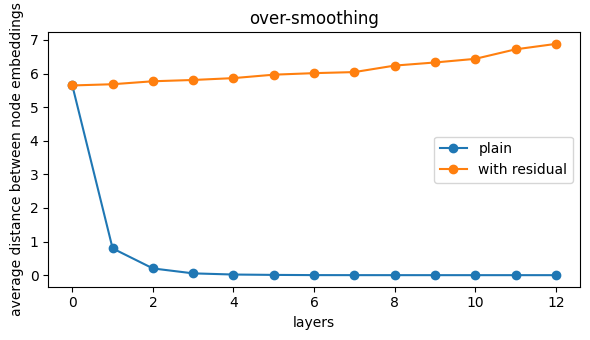

WARNING | plain         : 5.64 -> 0.0001
SUCCESS | with residual : 5.64 -> 6.88


In [22]:
torch.manual_seed(0)
g_pos = torch.randn(60, 3)
d = torch.cdist(g_pos, g_pos); d.fill_diagonal_(float("inf"))
idx = d.topk(4, largest=False).indices
dst_ = torch.arange(60).unsqueeze(1).expand(-1, 4).reshape(-1)
demo_ei = torch.unique(torch.cat([torch.stack([idx.reshape(-1), dst_]),
                                  torch.stack([dst_, idx.reshape(-1)])], 1), dim=1)

def spread(h):
    """average pairwise distance between node embeddings"""
    return torch.cdist(h, h).mean().item()

curves = {}
for use_residual in [False, True]:
    torch.manual_seed(0)
    h = torch.randn(60, 16)
    layers = [nn.Linear(16, 16) for _ in range(12)]
    vals = [spread(h)]
    with torch.no_grad():
        for lin in layers:
            agg = torch.zeros_like(h).index_add_(0, demo_ei[1], h[demo_ei[0]])
            deg = torch.zeros(60).index_add_(0, demo_ei[1], torch.ones(demo_ei.size(1))).clamp(min=1)
            new = torch.relu(lin(agg / deg.unsqueeze(1)))
            h = h + new if use_residual else new
            vals.append(spread(h))
    curves["with residual" if use_residual else "plain"] = vals

plt.figure(figsize=(6, 3.5))
for k, v in curves.items():
    plt.plot(v, "o-", label=k)
plt.xlabel("layers"); plt.ylabel("average distance between node embeddings")
plt.title("over-smoothing"); plt.legend(); plt.tight_layout(); plt.show()

logger.warning(f"plain         : {curves['plain'][0]:.2f} -> {curves['plain'][-1]:.4f}")
logger.success(f"with residual : {curves['with residual'][0]:.2f} -> {curves['with residual'][-1]:.2f}")

## 📖 Readout: from nodes to a graph

Sometimes you want one vector for the whole graph. The rule is the same as before: whatever
you do must not depend on node order. So: sum, mean, or max over all nodes.

And the same expressiveness argument applies. Sum-pooling can tell a graph apart from two
disconnected copies of itself. Mean-pooling cannot, because the average is unchanged.

⚠ In this project we do **not** use readout for the final prediction, and it is worth
understanding why now. ΔΔG is a question about **one specific residue**: what happens if I
change *this* amino acid? Squashing the protein into a single vector throws away exactly the
information we need. We will keep per-residue embeddings all the way through. This turns out
to matter a great deal in Part 7.

## 🛠 Exercise 2.5: readout

When you batch several graphs together, PyTorch Geometric stacks all their nodes into one
big tensor and gives you a `batch` vector saying which graph each node came from:
`batch = [0,0,0,1,1,2]` means the first three nodes are graph 0, the next two are graph 1,
and the last is graph 2.

Sum the node features within each graph. Same tool as always.

In [24]:
def global_sum_pool(x, batch, num_graphs):
    out = torch.zeros(num_graphs, x.size(1))
    out.index_add_(0, batch, x)
    return out

In [25]:
from gjepa.checks import check_global_pool

check_global_pool(global_sum_pool)

SUCCESS |   PASS   one row per graph
SUCCESS |   PASS   sums are correct
SUCCESS |   PASS   distinguishes a graph from a bigger one
SUCCESS | Exercise 2.5 (readout)  3/3 checks passed


True

## 📖 The layers you will actually use

You have now built the machinery by hand, so the named architectures should look like small
variations rather than magic:

| layer | AGGREGATE | uses edge features? | notes |
|---|---|---|---|
| **GCN** | normalised mean | no (scalar weights only) | the classic, cheap, blind to counting |
| **GraphSAGE** | mean or max | no | keeps a separate self-weight |
| **GAT / GATv2** | weighted mean (attention) | yes | learns which neighbours matter |
| **GIN / GINE** | **sum** | GINE yes, GIN no | maximally expressive under 1-WL |

⚠ Look hard at the "uses edge features" column. Our edges carry the **distance between
residues**, which is most of the geometric information in a protein structure. Pick `GCNConv`
or `SAGEConv` and you throw all of it away before training even starts. Your model will still
run. It will just be working blindfolded.

> ⚠ **Attention is a weighted mean.** GAT's coefficients are softmax-normalised, so they sum
> to 1. In theory that means GAT inherits mean's counting weakness. Whether it does in
> practice, on this task, is genuinely open, and it is one of the experiments in Part 9.

## 🔬 Explore

No checker here. Poke at things.

* Change Demo 2.1 to a **ring** (connect node 4 back to node 0) or a **star** (every node
  connected only to node 0). How does the receptive field change?
* In Demo 2.3, try `mean` aggregation versus `sum`. Does over-smoothing get better or worse?
  Why might that be?
* Your `MyGNNLayer` uses sum aggregation. Swap in `aggregate_mean` and re-run the checker.
  Which properties still pass? Which fail, and does the failure make sense?
* What happens to over-smoothing if you make the graph denser (`topk(10)` instead of
  `topk(4)`)? Predict first.

---
# Part 3: 🧬 Proteins as graphs

## 📖 What a protein is, in five paragraphs

A protein is a chain. The links in the chain are **amino acids**, also called **residues**,
and there are twenty different kinds. Your cells build a protein by stringing them together
in an order written down in your DNA. A small protein might be 50 residues long, a large one
a few thousand.

The twenty residues differ in what hangs off the side of the chain. Some side chains are
**hydrophobic**, meaning they hate water. Some are **polar** or **charged**, meaning they get
along with water fine. Some are big, some are tiny, one of them (proline) is so awkwardly
shaped that it puts a kink in the chain wherever it appears.

Now drop that chain into water. The hydrophobic residues are miserable, so the chain
scrunches up to bury them in the middle, away from the water, while the polar ones stay on
the outside. It does this fast, in microseconds to seconds, and it does it **reproducibly**:
the same sequence gives you the same shape every time. That shape is called the **fold**, and
it is what the protein actually does its job with.

The fold is held together by a large number of individually weak interactions. Physicists
will recognise the setup: the folded state sits at a free energy minimum, and the quantity
that matters is the **difference** in free energy between folded and unfolded. That is **ΔG**.
A bigger ΔG means a more stable protein, one that needs more heat or more denaturant before
it falls apart.

Now mutate one residue. Replace a buried hydrophobic one with a charged one and you have
just put a charge in the greasy core, which the protein hates, so ΔG drops and the protein
is less stable. The change in stability is **ΔΔG = ΔG(mutant) − ΔG(wild type)**, and it is
the number we are going to predict. Negative means the mutation destabilises.

## 📖 Why we need the structure and not just the sequence

Here is the thing that makes this a graph problem rather than a text problem.

Whether a mutation hurts depends almost entirely on **where the residue sits in the folded
structure**. The same substitution, say leucine to aspartate, is catastrophic if the residue
is buried in the core and completely harmless if it is out on the surface. Two residues that
are 80 positions apart in the sequence can be pressed against each other in the fold.

A model that only sees the sequence has to infer all of that indirectly. A model that sees
the structure gets it for free. So:

* **node** = one residue, carrying which amino acid it is
* **edge** = two residues that are close in 3D space
* **edge features** = how far apart in space, and how far apart along the chain

We place each residue at the position of its **Cα atom**, the central carbon of the backbone.
It is a coarse summary of where the residue is, and it is enough.

<img src="https://raw.githubusercontent.com/zenwor/sciml26_gjepa/main/notebooks/figures/protein_graph.png" width="760">

<sub>A real SCOP protein from our own pretraining corpus, drawn three ways.</sub>

## 🛠 Exercise 3.1: build the contact graph

Given `pos` of shape `[N, 3]`, connect every residue to its `k` nearest neighbours.

Three things the checker insists on:

1. **no self-loops.** A residue is trivially its own nearest neighbour. Exclude it, or every
   node will spend one of its `k` connections talking to itself.
2. **undirected.** If `i` is a neighbour of `j`, message passing needs `j -> i` as well as
   `i -> j`. Add the flipped edges and de-duplicate.
3. the neighbours really are the nearest ones.

`torch.cdist(pos, pos)` gives you all pairwise distances. `Tensor.topk(k, largest=False)`
gives you the smallest ones. To exclude self-distances, set the diagonal to infinity first
with `fill_diagonal_`.

In [26]:
def knn_edges(pos, k):
    # 1. pairwise distances
    dist = torch.cdist(pos, pos)
    # 2. no self-loops
    dist.fill_diagonal_(float('inf'))
    # 3. find k nearest neighbors
    idx = dist.topk(k, largest=False).indices
    # 4. build edge_index
    src = torch.arange(pos.size(0)).unsqueeze(1).expand(-1, k).reshape(-1)
    dst = idx.reshape(-1)
    edge_index = torch.stack([src, dst], dim=0)
    # 5. add reverse edges and deduplicate
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    edge_index = torch.unique(edge_index, dim=1)
    return edge_index

In [27]:
from gjepa.checks import check_knn_edges

check_knn_edges(knn_edges, k=3)

SUCCESS |   PASS   returns an edge_index
SUCCESS |   PASS   no self loops
SUCCESS |   PASS   every edge has its reverse
SUCCESS |   PASS   neighbours really are the nearest ones
SUCCESS | Exercise 3.1 (kNN graph)  4/4 checks passed


True

## 🔍 Demo 3.1: look at a real protein

Now a real one. Note the two panels.

The **contact map** is the adjacency matrix drawn as an image. The thick diagonal is the
chain itself, since residue `i` is always near residue `i+1`. The interesting parts are the
stripes **off** the diagonal: those are pieces of the chain that are far apart in sequence
and touching in space. That is the fold. A sequence-only model sees none of it.

The second panel splits contacts by how far apart the two residues are along the chain.

INFO    | 233 residues, 4288 contacts
INFO    | sequence: GHSKWANTRHRKAAQDAKRGKIFTKIIRELVTAAKLDANPRLRAAVDKALSNNMTRDTLN...


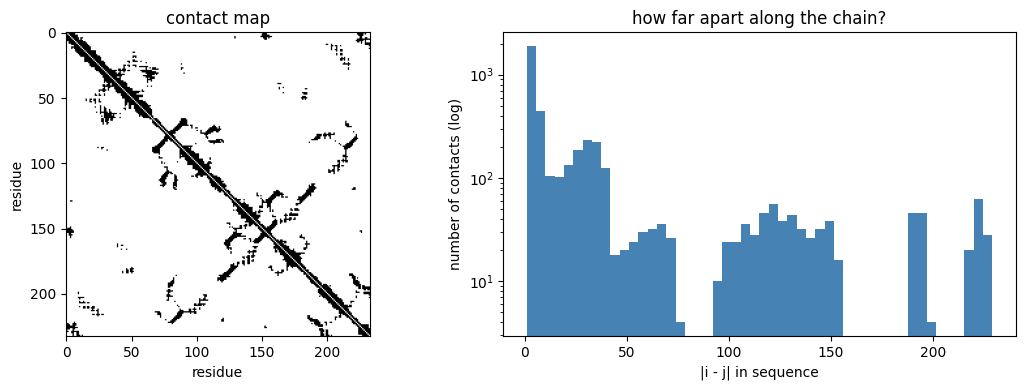

INFO    | 47% of contacts are long-range (more than 8 apart in sequence)
INFO    | Those are the ones that define the fold. A sequence model cannot see them.


In [28]:
from gjepa.protein.data import load_scop

protein = load_scop(limit=1)[0]
src, dst = protein.edge_index
separation = (src - dst).abs()

logger.info(f"{protein.num_nodes} residues, {protein.edge_index.size(1)} contacts")
logger.info(f"sequence: {protein.seq[:60]}...")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
adj = torch.zeros(protein.num_nodes, protein.num_nodes)
adj[src, dst] = 1
ax[0].imshow(adj, cmap="Greys")
ax[0].set_title("contact map"); ax[0].set_xlabel("residue"); ax[0].set_ylabel("residue")
ax[1].hist(separation.numpy(), bins=50, color="steelblue")
ax[1].set_yscale("log"); ax[1].set_title("how far apart along the chain?")
ax[1].set_xlabel("|i - j| in sequence"); ax[1].set_ylabel("number of contacts (log)")
plt.tight_layout(); plt.show()

long_range = (separation > 8).float().mean()
logger.info(f"{long_range:.0%} of contacts are long-range (more than 8 apart in sequence)")
logger.info("Those are the ones that define the fold. A sequence model cannot see them.")

## 🔬 Explore

* Rebuild the graph with `k = 4` and with `k = 32` using your `knn_edges`. How does the
  contact map change? At what point does it stop looking like a fold and start looking like
  a blur?
* What fraction of contacts are long-range at each `k`? Is a bigger `k` adding structure or
  adding noise?
* Try a distance cutoff (connect everything within 8 Å) instead of a fixed `k`. What happens
  to residues in the dense core versus ones sticking out on a loop? Which do you think is a
  better inductive bias, and why?

---
# Part 4: 🎭 Self-supervised learning

## 📖 The problem, in numbers

We have **271,231** ΔΔG measurements. Each one is real laboratory work. That dataset,
published in *Nature* in 2023, was a genuine landmark precisely because it was so much bigger
than anything before it.

Meanwhile there are hundreds of thousands of solved protein structures sitting in public
databases, free, and hundreds of millions more predicted by AlphaFold.

Supervised learning can only use the first number. Everything in this part is about how to
use the second.

> Yann LeCun put it in a way that stuck, in a 2016 talk: *if intelligence is a cake, the bulk
> of the cake is self-supervised learning, the icing is supervised learning, and the cherry
> on top is reinforcement learning.* He originally said "unsupervised" and later corrected
> himself to "self-supervised". The correction is the whole point. The learning signal is not
> coming from nowhere. It is coming from the structure of the data itself.

## 📖 A short history, and what each era got wrong

**Autoencoders (2006 onward).** Squeeze the input through a bottleneck and reconstruct it.
If a small vector is enough to rebuild the input, that vector must have captured something.
True, but what it captures is whatever is cheapest to compress, which is often not what you
want.

**Word embeddings (2013).** word2vec: predict a word from its neighbours. The famous result
was that arithmetic started working, `king - man + woman ≈ queen`. This was the first loud
demonstration that a made-up prediction task could produce genuinely useful representations.

**Pretext tasks (2015 to 2018).** Invent a puzzle whose answer you already know. Cut an image
into tiles and predict their arrangement, like a jigsaw. Rotate an image by 0, 90, 180 or 270
degrees and predict the rotation. Remove the colour and predict it back. These worked, but the
tasks were arbitrary, and a network good at predicting rotation learns rotation-relevant
features, which may or may not overlap with what you actually needed. The features were a
side effect.

**Contrastive learning (2018 to 2020).** Stop inventing puzzles. Take two random crops of the
same photo and say "these two should have similar representations", then take a crop of a
different photo and say "this one should be different". SimCLR and MoCo. It worked very well
and it cost two things: you need a lot of negative examples in every batch, and your results
depend enormously on exactly which augmentations you chose.

> **Figure to add.** SimCLR Figure 2 is drawn in TikZ, so it is not in the arXiv
> source and `scripts/fetch_figures.py` cannot pull it. Open
> <https://ar5iv.labs.arxiv.org/html/2002.05709>, save Figure 2 as
> `figures/simclr_framework.png`, then replace this block with an image tag.

**Non-contrastive (2020 to 2021).** BYOL showed you can throw away the negatives entirely and
still not collapse, using an asymmetry between two branches. This surprised people enough
that a small literature appeared arguing about why it works at all.

**Masked modelling (2018 to 2022).** Hide part of the input and reconstruct it. BERT did it
for text and changed the field. MAE did it for images by masking 75% of the patches and
rebuilding the pixels.

<img src="https://raw.githubusercontent.com/zenwor/sciml26_gjepa/main/notebooks/figures/mae_reconstructions.png" width="760">

<sub>He et al., <i>Masked Autoencoders Are Scalable Vision Learners</i>, CVPR 2022, Figure 2. Masked input, MAE's reconstruction, and the original.</sub>

<img src="https://raw.githubusercontent.com/zenwor/sciml26_gjepa/main/notebooks/figures/mae_architecture.png" width="620">

<sub>He et al., MAE, CVPR 2022, Figure 1. Note the asymmetry: a big encoder that only
sees the visible patches, and a small decoder that rebuilds the pixels. The decoder is
thrown away afterwards, which is a hint about what is really being learned.</sub>

**JEPA (2022 onward).** Hide part of the input and predict its **representation** rather than
the input itself. That is Part 5.

## 📖 The failure mode that will bite you: collapse

Every method above that says "make these two representations similar" has an embarrassing
trivial solution:

> **map every possible input to the same constant vector.**

The two representations are now perfectly similar. Loss zero. Congratulations, your model has
learned the number 7 and nothing else.

There are two flavours and the second is far more dangerous:

* **complete collapse.** Every output is identical. Obvious the moment you look.
* **dimensional collapse.** Outputs do vary, but only inside a tiny subspace of the embedding
  space. Most directions carry no information at all. **The loss looks completely healthy.**

We hit dimensional collapse in this very project. Our pretrained encoder was using roughly
**3 of its 128 dimensions**, and the loss curve was beautiful the whole time.

So: **watch the spread of your embeddings, not the loss.** A loss going to zero while the
variance goes to zero is not a good run. It is the model finding the exit.

## 🔍 Demo 4.1: watch a model collapse

The smallest possible version. An encoder, two noisy views of the same data, and a loss
saying "make their embeddings match".

We run it twice. Once naively, and once with the fix everyone uses: a **second copy of the
encoder** that receives no gradient (a **stop-gradient**) and is updated slowly by copying
the first one a little at a time (an **exponential moving average**, or EMA).

**Guess before you run:** which run will have the lower final loss?

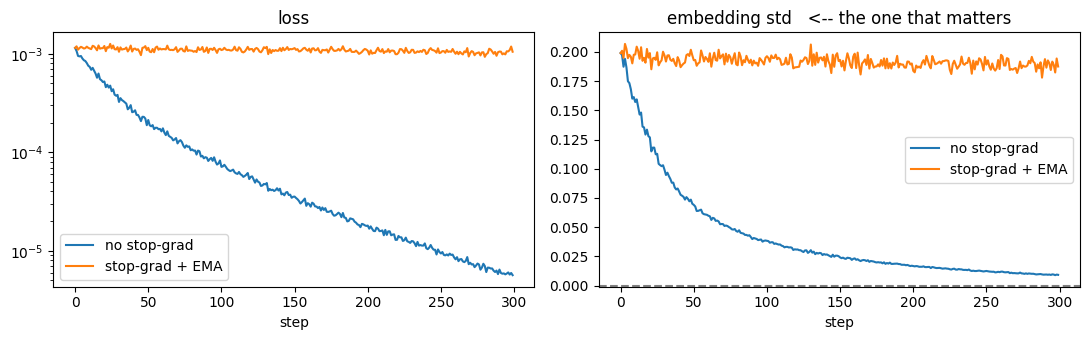

ERROR   | no stop-grad     : final loss 5.65e-06   std 0.0091   <- COLLAPSED
SUCCESS | stop-grad + EMA  : final loss 1.05e-03   std 0.1875


In [29]:
def collapse_demo(use_stopgrad, steps=300, dim=32):
    torch.manual_seed(0)
    enc = nn.Sequential(nn.Linear(16, 64), nn.ReLU(), nn.Linear(64, dim))
    target_enc = nn.Sequential(nn.Linear(16, 64), nn.ReLU(), nn.Linear(64, dim))
    target_enc.load_state_dict(enc.state_dict())
    for p in target_enc.parameters():
        p.requires_grad_(False)
    opt = torch.optim.Adam(enc.parameters(), lr=1e-3)

    hist = []
    for _ in range(steps):
        x = torch.randn(128, 16)
        view1, view2 = x + 0.1 * torch.randn_like(x), x + 0.1 * torch.randn_like(x)

        z1 = enc(view1)
        if use_stopgrad:
            with torch.no_grad():                    # the target branch is frozen...
                z2 = target_enc(view2)
        else:
            z2 = enc(view2)                          # ...or it is not

        loss = F.mse_loss(z1, z2)
        opt.zero_grad(); loss.backward(); opt.step()

        if use_stopgrad:                             # EMA: teacher drifts toward student
            with torch.no_grad():
                for q, k in zip(enc.parameters(), target_enc.parameters()):
                    k.mul_(0.99).add_(0.01 * q)

        hist.append((loss.item(), z1.std(0).mean().item()))
    return np.array(hist)


no_sg, with_sg = collapse_demo(False), collapse_demo(True)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for h, lab in [(no_sg, "no stop-grad"), (with_sg, "stop-grad + EMA")]:
    ax[0].plot(h[:, 0], label=lab); ax[1].plot(h[:, 1], label=lab)
ax[0].set_title("loss"); ax[0].set_yscale("log")
ax[1].set_title("embedding std   <-- the one that matters")
ax[1].axhline(0, ls="--", c="grey")
for a_ in ax:
    a_.set_xlabel("step"); a_.legend()
plt.tight_layout(); plt.show()

logger.error(f"no stop-grad     : final loss {no_sg[-1,0]:.2e}   std {no_sg[-1,1]:.4f}   <- COLLAPSED")
logger.success(f"stop-grad + EMA  : final loss {with_sg[-1,0]:.2e}   std {with_sg[-1,1]:.4f}")

The naive run has a loss **hundreds of times lower**. It also learned nothing. If you had
only been watching the loss, you would have shipped it.

This is the single most useful habit in this entire notebook: **plot the embedding spread
next to the loss, always.**

## 🛠 Exercise 4.1: the EMA update

You just saw it inline. Write it properly, because you will need it in Part 7.

$$\theta_{\text{teacher}} \leftarrow m\,\theta_{\text{teacher}} + (1-m)\,\theta_{\text{student}}$$

With `m = 0.99` the teacher moves 1% of the way toward the student on each call, so it lags
behind by roughly a hundred steps. That lag is the point. The student is chasing a target
that keeps moving away from wherever it is heading, which is what makes the constant solution
unreachable.

⚠ Update in place (`p.data.mul_(...)`, `p.data.add_(...)`) and do it under `torch.no_grad()`.
Rebinding the parameters instead would silently detach the teacher from the optimiser's view
of the world.

In [ ]:
def ema_update(student, teacher, m=0.99):
    # The teacher should never receive gradients directly.
    # It only moves slowly toward the student using this formula:
    # teacher = m * teacher + (1 - m) * student
    # hi
    # With m=0.99 the teacher moves 1% of the way each step,
    # so it always lags about 100 steps behind the student.
    # That lag is the whole point. The student is chasing a target
    # that keeps moving away, which makes the trivial solution
    # of mapping everything to the same vector impossible to reach.
    with torch.no_grad():
        for s_param, t_param in zip(student.parameters(), teacher.parameters()):
            t_param.data = m * t_param.data + (1 - m) * s_param.data

In [31]:
from gjepa.checks import check_ema

check_ema(ema_update)

SUCCESS |   PASS   uses the right formula
SUCCESS |   PASS   m=0 makes teacher a copy of student
SUCCESS |   PASS   repeated updates converge
SUCCESS |   PASS   updates in place
SUCCESS | Exercise 4.1 (EMA update)  4/4 checks passed


True

## 🔬 Explore

* In `collapse_demo`, change the EMA momentum from `0.99` to `0.5`, then to `0.999`, then to
  `1.0`. One of these collapses and one of them stops learning entirely. Predict which is
  which before running, then explain the results to each other.
* Remove the EMA update but keep the `no_grad` (so the teacher is frozen at its random
  initialisation forever). Does it collapse? What is the student actually learning?
* The two views here differ only by Gaussian noise. Make the noise much larger. At what point
  does the task become impossible, and how would you tell from the plots?

---
# Part 5: 🔮 JEPA

## 📖 The argument

**J**oint **E**mbedding **P**redictive **A**rchitecture. Proposed by **Yann LeCun** in a 2022
position paper, *A Path Towards Autonomous Machine Intelligence*
([OpenReview](https://openreview.net/forum?id=BZ5a1r-kVsf)).

Start with what is wrong with masked reconstruction. Mask a patch of an image and ask a model
to fill in the pixels. To do well it has to commit to an exact answer: this pixel is
`(137, 92, 40)`. But much of that detail is genuinely unknowable from the context. The exact
texture of the grass, the precise noise pattern. The model spends real capacity getting those
right, and they were never the point.

The protein version is sharper. Mask a loop on the surface of a protein and ask what is there.
Loops are floppy. There may be several perfectly reasonable answers. Forcing the model to
pick one and punishing it for the others is teaching it something false.

LeCun's move:

> **Do not predict the input. Predict its representation.**

An encoder is allowed to **throw away** whatever it cannot predict. If the exact loop
conformation is unknowable, the representation simply does not encode it, and the prediction
task stops asking about it.

That freedom to discard is the whole idea. It is also, and you saw this coming, exactly why
these models collapse: discarding **everything** is also a solution.

<img src="https://raw.githubusercontent.com/zenwor/sciml26_gjepa/main/notebooks/figures/arch_joint_embedding.png" width="250"> <img src="https://raw.githubusercontent.com/zenwor/sciml26_gjepa/main/notebooks/figures/arch_generative.png" width="250"> <img src="https://raw.githubusercontent.com/zenwor/sciml26_gjepa/main/notebooks/figures/arch_jepa.png" width="250">

<sub>Assran et al., I-JEPA, CVPR 2023, Figure 1. Left: joint-embedding, which asks whether two inputs match. Middle: generative, which reconstructs y from x. Right: JEPA, which predicts the <i>representation</i> of y from x, given a variable z saying which part of y we mean.</sub>

## 📖 The architecture

```
     context x ──► context encoder  (trainable)  ──► z_x
                                                      │
                          target position code  ──►   +   ──► predictor ──► ŷ
                                                                             │
     target y  ──► target encoder  (EMA, stop-grad) ──► z_y ────────────────► loss
```

| piece | job | the detail that matters |
|---|---|---|
| **context encoder** | encode what you can see | trainable, receives gradients |
| **target encoder** | produce the regression targets | an **EMA copy** of the context encoder with a stop-gradient. You built this in Exercise 4.1 |
| **predictor** | map context to predicted target representation | **deliberately weaker** than the encoders |
| **loss** | L2 or smooth-L1 **in embedding space** | never in input space |

### Two choices that look arbitrary and are not

**The predictor is deliberately crippled.** In I-JEPA the encoder is a Vision Transformer
with embedding dimension 1280 and the predictor is a narrow one with dimension **384**. The
reasoning: if the predictor is powerful enough, it can solve the prediction task on its own
without the encoder ever needing to learn anything useful. The loss goes down, the features
stay junk. This failure has a name in the JEPA literature: **silent collapse**.

**The predictor is told where the target is.** It receives a position code identifying which
piece it is being asked about. Take that away and the best possible strategy is to predict the
**average of all targets**, which is yet another way to get a nice-looking loss out of a model
that has learned nothing. Demo 5.1 shows exactly this.

## 🔍 Demo 5.1: why the predictor must know *where*

Same context vector, two different targets. With a position code the predictor can give
different answers. Without one, it is being asked the identical question twice and there is
no way for it to answer differently.

In [32]:
torch.manual_seed(0)
dim = 32
predictor = nn.Sequential(nn.Linear(dim, 64), nn.ReLU(), nn.Linear(64, dim))

context = torch.randn(8, dim)                                # the same context...
pos_a, pos_b = torch.randn(8, dim), torch.randn(8, dim)      # ...two different targets

with torch.no_grad():
    with_pos_a, with_pos_b = predictor(context + pos_a), predictor(context + pos_b)
    without_pos = predictor(context)

logger.success(f"WITH position code    : predictions differ by "
               f"{(with_pos_a - with_pos_b).abs().mean():.4f}")
logger.warning("WITHOUT position code : the predictor receives identical input for both")
logger.warning("                        targets, so it must produce identical output. 0.0000")
logger.warning("A model in that situation minimises its loss by predicting the mean of all")
logger.warning("targets. The loss falls. Nothing is learned.")

SUCCESS | WITH position code    : predictions differ by 0.2530
WARNING | WITHOUT position code : the predictor receives identical input for both
WARNING |                         targets, so it must produce identical output. 0.0000
WARNING | A model in that situation minimises its loss by predicting the mean of all
WARNING | targets. The loss falls. Nothing is learned.


## 📖 I-JEPA, the version that makes it click

[arXiv 2301.08243](https://arxiv.org/abs/2301.08243), Assran et al., CVPR 2023. Images, and
by far the most intuitive entry point.

1. Cut the image into patches.
2. Choose **one large context block**, 85 to 100% of the image.
3. Choose **4 small target blocks**, 15 to 20% each, and **remove them from the context**.
4. Encode the context. For each target, predict its patch representations, telling the
   predictor where that target sits.
5. Compare against an EMA copy of the encoder that saw the **unmasked** image.

<img src="https://raw.githubusercontent.com/zenwor/sciml26_gjepa/main/notebooks/figures/ijepa_architecture.png" width="640">

<sub>Assran et al., I-JEPA, CVPR 2023, Figure 2. Compare this against the ASCII diagram above: context encoder, target encoder, predictor, L2 loss in embedding space.</sub>

<img src="https://raw.githubusercontent.com/zenwor/sciml26_gjepa/main/notebooks/figures/ijepa_masking.png" width="760">

<sub>Assran et al., I-JEPA, CVPR 2023, Figure 3. One large context block, four small target blocks. Exercise 6.1 is the protein version of this.</sub>

Worth noting: the EMA momentum ramps from 0.996 to 1.0 over training, targets are LayerNormed
before comparison, and the whole thing trained on 16 A100s in under 72 hours, which its
authors point out is several times less compute than comparable methods.

And the headline: **no hand-crafted augmentations at all.** No colour jitter, no crops as
views, nothing. Compare that with contrastive learning, where the augmentation recipe more or
less *is* the method.

## 📖 Where JEPA sits among its neighbours

| | predicts what? | needs negatives? | needs augmentations? | collapse prevented by |
|---|---|---|---|---|
| **Contrastive** (SimCLR) | agreement between two augmented views | **yes** | yes, and results depend heavily on them | pushing negatives apart |
| **Masked autoencoder** (MAE) | **the masked input itself** | no | no | cannot collapse, but spends capacity on unpredictable detail |
| **BYOL / SimSiam** | the representation of **another augmented view of the same input**, so it learns *invariance to augmentation* | no | **yes, they are the entire signal** | stop-grad + predictor + EMA |
| **JEPA** | the representation of a **different part** of the input, told *where* that part is, so it learns *predictive structure* | no | no | stop-grad + EMA + weak predictor |

> **One sentence worth memorising.**
> MAE predicts the input. BYOL predicts a distorted copy of the input's representation.
> **JEPA predicts the representation of a different piece of the input, told only where that
> piece is.**

That "told only where" is why the I-JEPA authors describe their predictor as a *primitive
world model* rather than an invariance learner. It has to have some internal notion of how
the parts of a thing relate to each other in order to answer at all.

---
# Part 6: 🕸🎭 Self-supervised learning on graphs

## 📖 What can you even hide?

Everything so far was invented for images and text. Graphs give you more places to hide
things, and they behave differently.

| hide this | and the task becomes | used by |
|---|---|---|
| **node features** | predict the missing attributes | AttrMask, GraphMAE |
| **node identity** | which atom or residue belongs here? | masked-residue models, and us |
| **edges** | reconstruct the adjacency | GAE/VGAE, S2GAE |
| **a whole subgraph** | say something about the removed region | ContextPred, **Graph-JEPA** |
| **nothing, build two views instead** | contrast them | GraphCL, GRACE, MVGRL |

<img src="https://raw.githubusercontent.com/zenwor/sciml26_gjepa/main/notebooks/figures/graph_ssl_architectures.png" width="760">

<sub>Skenderi et al., TMLR 2024, Figure 1. The three families of graph SSL side by
side: contrastive, generative, and predictive. Ours is the one on the right.</sub>

## 📖 The trap that does not exist in image-land

Image augmentations are safe by construction. Rotate a cat, still a cat. Adjust the
brightness, still a cat. The label survives whatever you do.

**Graph augmentations are not safe.** Delete one atom from a molecule and you have a
different molecule with different chemistry. Drop the wrong contact in a protein and you may
have removed the interaction holding two helices together.

This is why GraphCL, one of the best-known graph contrastive papers, is largely an empirical
study of *which augmentations to use on which dataset*. There is no universally safe recipe,
because the augmentation that preserves the label for social networks destroys it for
molecules.

It is also the strongest argument for using JEPA on graphs specifically: **it needs no
augmentations at all.**

## 🔍 Demo 6.1: how dangerous is an augmentation, really?

Two standard graph augmentations on a real protein. One of them is a catastrophe and the
other is almost harmless, and **which is which is not obvious in advance**. That is the real
lesson here: measure what your augmentation does before you trust it.

**Guess before you run:** which of the two do you expect to be worse?

In [33]:
seq = protein.seq

logger.info(f"protein: {protein.num_nodes} residues, {protein.edge_index.size(1)} contacts")
logger.info("")
logger.info("A) node dropping: delete residue 10")
aug = seq[:10] + seq[11:]
wrong = sum(1 for p in range(10, len(aug)) if aug[p] != seq[p])
logger.info(f"   original : {seq[:38]}")
logger.info(f"   augmented: {aug[:38]}")
logger.error(f"   -> {wrong}/{len(aug) - 10} positions now hold a DIFFERENT amino acid")
for p in [12, 25, 40]:
    logger.warning(f"      a label saying 'position {p} is {seq[p-1]}' now points at '{aug[p-1]}'")

logger.info("")
logger.info("B) edge dropping: remove random contacts")
longrange = (src - dst).abs() > 8
for frac in [0.1, 0.3, 0.5]:
    torch.manual_seed(0)
    keep = torch.rand(src.numel()) > frac
    had = torch.zeros(protein.num_nodes, dtype=torch.bool); had[dst[longrange]] = True
    still = torch.zeros(protein.num_nodes, dtype=torch.bool); still[dst[longrange & keep]] = True
    logger.info(f"   drop {frac:>4.0%}: {int((longrange & keep).sum()):>4}/{int(longrange.sum())} "
                f"long-range contacts kept, {int((had & ~still).sum())} residues lose all of theirs")

INFO    | protein: 233 residues, 4288 contacts
INFO    | 
INFO    | A) node dropping: delete residue 10
INFO    |    original : GHSKWANTRHRKAAQDAKRGKIFTKIIRELVTAAKLDA
INFO    |    augmented: GHSKWANTRHKAAQDAKRGKIFTKIIRELVTAAKLDAN
ERROR   |    -> 206/222 positions now hold a DIFFERENT amino acid
WARNING |       a label saying 'position 12 is K' now points at 'A'
WARNING |       a label saying 'position 25 is K' now points at 'I'
WARNING |       a label saying 'position 40 is P' now points at 'R'
INFO    | 
INFO    | B) edge dropping: remove random contacts
INFO    |    drop  10%: 1812/2022 long-range contacts kept, 0 residues lose all of theirs
INFO    |    drop  30%: 1412/2022 long-range contacts kept, 1 residues lose all of theirs
INFO    |    drop  50%: 1011/2022 long-range contacts kept, 4 residues lose all of theirs


**Read those two against each other.**

**Node dropping is a disaster, and a silent one.** Deleting a single residue shifts every
position after it by one. In this project every ΔΔG label is indexed by position, so this
augmentation would quietly mislabel almost the entire training set while everything continued
to run without a single error message.

**Edge dropping is surprisingly benign.** A k-nearest-neighbour contact graph carries enough
redundancy that even removing half the contacts leaves nearly every residue still anchored.

Neither of those was obvious before measuring. If you use augmentations in Part 9, measure
first.

## 📖 Be sceptical: the honest literature

Before you get attached to any of this, read these three. They are the reason this notebook
insists on proper controls.

* **"Graph Contrastive Learning versus Untrained Baselines"**
  ([arXiv 2509.01541](https://arxiv.org/abs/2509.01541), 2025). Randomly initialised,
  completely **untrained** GNNs frequently match or beat graph contrastive methods. On some
  datasets a handcrafted degree histogram wins outright.
* **Errica et al., "A Fair Comparison of GNNs for Graph Classification"**
  ([arXiv 1912.09893](https://arxiv.org/abs/1912.09893), ICLR 2020). On several standard
  benchmarks, **no GNN beat a baseline that ignored the graph structure entirely.**
* **"Does GNN Pretraining Help Molecular Representation?"**
  ([arXiv 2207.06010](https://arxiv.org/abs/2207.06010), NeurIPS 2022). Self-supervised graph
  pretraining often gives no statistically significant gain at all.

The control that matters most is the **randomly initialised encoder**. If your pretrained
model cannot beat random weights, you have learned nothing, and you would be surprised how
often that control is quietly missing from published work. You will run it in Part 8.

## 🛠 Exercise 6.1: masking a structural region

Now the piece our model actually needs.

Instead of scattering masked residues randomly through the protein, hide a **contiguous piece
of the fold**: pick a seed residue, then take its nearest neighbours in 3D.

Why it matters. If you mask at random, almost every hidden residue still has unmasked
neighbours on both sides, so the model can fill it in from local context without
understanding anything. Masking a whole region forces it to reason about a piece of structure
it genuinely cannot see. This is the direct analogue of I-JEPA taking large contiguous
**blocks** of an image rather than scattered pixels.

The checker measures whether your masked residues are actually spatially close together, so
a random mask will not pass.

In [37]:
def region_mask(pos, ratio=0.25):
    num_residues = pos.size(0)
    k = round(ratio * num_residues)

    # Everything we hide will be spatially close to this seed.
    seed = torch.randint(0, num_residues, (1,)).item()

    dist = torch.cdist(pos[seed].unsqueeze(0), pos).squeeze(0)

    # we take the k closest residues to the seed.
    # This gives us a compact spatial region rather than scattered random nodes,
    # which forces the model to reason about missing structure
    # instead of just interpolating between visible neighbors.
    indices = dist.topk(k, largest=False).indices

    mask = torch.zeros(num_residues, dtype=torch.bool)
    mask[indices] = True
    return mask

In [38]:
from gjepa.checks import check_region_mask

check_region_mask(region_mask)

SUCCESS |   PASS   returns a bool mask of the right size


SUCCESS |   PASS   masked residues are spatially close together
SUCCESS |   PASS   a different region each time
SUCCESS | Exercise 6.1 (region mask)  3/3 checks passed


True

## 🔍 Demo 6.2: see your mask in 3D

Your region mask against a random one, on a real protein. This is our own version of I-JEPA's
masking figure, drawn on our own data.

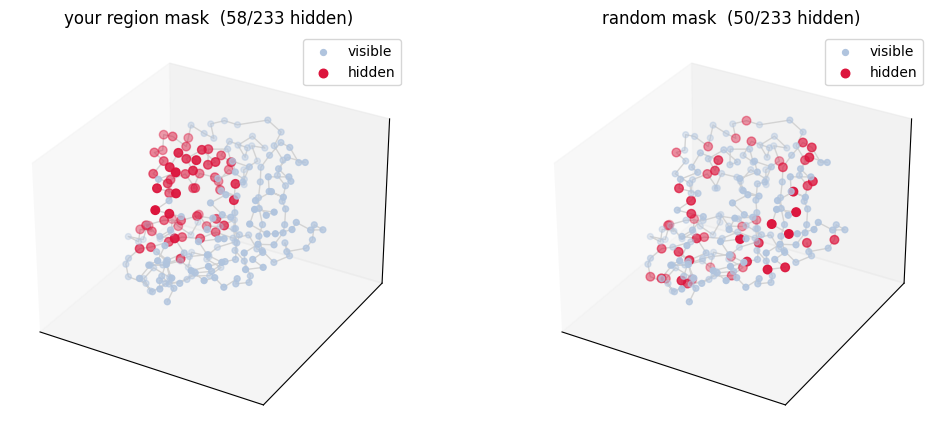

INFO    | region : masked residues are  14.1 Å apart on average
INFO    | random : masked residues are  23.3 Å apart on average
INFO    | whole  : the entire protein spans  23.5 Å


In [39]:
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

pos = protein.pos
fig = plt.figure(figsize=(11, 4.5))
for i, (name, mask) in enumerate([("your region mask", region_mask(pos, 0.25)),
                                  ("random mask", torch.rand(pos.size(0)) < 0.25)]):
    m = mask.numpy()
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    ax.plot(*pos.numpy().T, c="lightgrey", lw=1)
    ax.scatter(*pos.numpy()[~m].T, c="lightsteelblue", s=18, label="visible")
    ax.scatter(*pos.numpy()[m].T, c="crimson", s=38, label="hidden")
    ax.set_title(f"{name}  ({m.sum()}/{len(m)} hidden)")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([]); ax.legend()
plt.tight_layout(); plt.show()

for name, fn in [("region", lambda: region_mask(pos, 0.25)),
                 ("random", lambda: torch.rand(pos.size(0)) < 0.25)]:
    d = [torch.cdist(pos[m], pos[m]).mean().item() for m in (fn() for _ in range(20))]
    logger.info(f"{name:7s}: masked residues are {np.mean(d):5.1f} Å apart on average")
logger.info(f"{'whole':7s}: the entire protein spans {torch.cdist(pos, pos).mean():5.1f} Å")

## 🔬 Explore

* Change `ratio` to 0.1, 0.5, 0.75. MAE found 75% masking best for images. Look at the 3D
  plots: at what point is there simply not enough context left to reconstruct anything?
* Write a **sequence-contiguous** mask instead (hide residues `i` through `i+k` along the
  chain). Compare it with the spatial one in the 3D plot. Which is the harder task, and which
  is more biologically meaningful?
* Mask the residues with the **highest degree** (the buried core) versus the lowest (the
  surface). Which do you expect to be harder to predict? This is not idle: it is close to the
  question of which mutations matter.

---
# Part 7: 🛠 Build the model

## 📖 What we are building, and one design decision worth arguing about

Everything comes together here. The pretraining task, in one sentence:

> Hide the **identity** of a contiguous region of residues, leave the **structure** completely
> visible, and predict the **representations** of the hidden residues.

Read that again and notice what is and is not hidden. Every edge, every distance, every
coordinate stays exactly where it was. Only the answer to "which amino acid is this?" is
removed. So the model is being asked:

> *Given the shape of the pocket, what belongs in it?*

That question is almost exactly the downstream question. ΔΔG asks: *how bad is it to put
something else in this pocket?* The pretraining task and the real task share their inductive
bias, which is the best thing you can hope for from self-supervised pretraining.

### The design decision

The original Graph-JEPA paper ([arXiv 2309.16014](https://arxiv.org/abs/2309.16014)) is a
**graph-level** method. It chops the graph into patches, turns each patch into a single
vector, and plays I-JEPA on those patch vectors. It produces one representation per graph.

We are not doing that, and the reason is worth understanding because it is the kind of
judgement call you will have to make yourself in Part 9.

ΔΔG is a **per-residue** question. A graph-level representation has already thrown away the
information about which residue is which. Worse, in the graph-level design the EMA machinery
lives in the patch-token Transformer, which means that when you move to the downstream task
you can only reuse the small GNN underneath it and you discard most of what was pretrained.
I-JEPA transfers its *big* encoder; a naive graph-level port transfers the small one.

So we work at the residue level. The encoder **is** the GNN, which means 100% of what you
pretrain is what you fine-tune.

<img src="https://raw.githubusercontent.com/zenwor/sciml26_gjepa/main/notebooks/figures/graph_jepa_architecture.png" width="760">

<sub>Skenderi et al., <i>Graph-level Representation Learning with JEPA</i>, TMLR 2024. Note step (b): the graph is cut into subgraph patches, and each becomes one token. We work at the residue level instead, for the reason given above.</sub>

## 🛠 Exercise 7.1: the protein encoder

One embedding per residue. Signature: `forward(x, edge_index, edge_attr) -> [num_residues, dim]`.

You have two helpers already written, because turning raw integers and distances into vectors
is fiddly and not the interesting part:

* `ResidueEncoder(dim)` maps an amino-acid index to a vector. ⚠ Note that `x` holds
  **category indices**, not numbers with magnitudes. Amino acid 7 is not "seven times" amino
  acid 1. Feeding these into a `Linear` would silently invent an ordering that does not exist,
  which is why it goes through an `Embedding` instead.
* `GeometricEdgeEncoder(dim)` maps `(distance, sequence separation)` to a vector. It expands
  the distance into a set of radial basis functions first, which hands the network a smooth
  local basis rather than making it learn a sharp non-linearity from one scalar.

Use `GINEConv`, which consumes edge features. Two layers is plenty to start. Put a residual
connection around each one, for the reason you saw in Demo 2.3.

The checker verifies your encoder actually **uses** all three inputs: the graph, the
distances, and the residue identities. It is surprisingly easy to build something that
silently ignores one of them.

In [42]:
from torch_geometric.nn import GINEConv
from gjepa.encoders import ResidueEncoder, GeometricEdgeEncoder

class MyEncoder(nn.Module):
    def __init__(self, dim=64, n_layers=2):
        super().__init__()

        self.node_emb = ResidueEncoder(dim)


        # (3D distance and sequence separation) into a vector of the same size.
        self.edge_emb = GeometricEdgeEncoder(dim)

        # we staj stack n_layers of GINEConv, one after another.
        # Each layer lets information travel one more hop through the graph.
        # With 2 layers each residue can see residues two contacts away.
        # GINEConv uses sum aggregation which is the most expressive choice
        # as we saw in the multiset puzzle earlier.
        self.convs = nn.ModuleList([
            GINEConv(nn.Sequential(
                nn.Linear(dim, dim),
                nn.ReLU(),
                nn.Linear(dim, dim)
            )) for _ in range(n_layers)
        ])

        # BatchNorm stabilizes training by keeping activations
        # at a reasonable scale after each layer.
        self.norms = nn.ModuleList([
            nn.BatchNorm1d(dim) for _ in range(n_layers)
        ])

    def forward(self, x, edge_index, edge_attr):
        h = self.node_emb(x)
        e = self.edge_emb(edge_attr)

        for conv, norm in zip(self.convs, self.norms):
            h = norm(F.relu(conv(h, edge_index, e)) + h)

        return h

In [43]:
from gjepa.checks import check_encoder

check_encoder(MyEncoder(dim=64), dim=64)

SUCCESS |   PASS   one embedding per residue
SUCCESS |   PASS   uses the contact graph
SUCCESS |   PASS   uses the edge features (distances)
SUCCESS |   PASS   uses the amino-acid identity
SUCCESS | Exercise 7.1 (protein encoder)  4/4 checks passed


True

## 🛠 Exercise 7.2: the JEPA objective

The five steps:

1. Copy `batch.x` and set the masked residues to `MASK_IDX`. ⚠ **Copy it.** If you write into
   `batch.x` in place you have permanently damaged that protein for every future epoch, and
   nothing will tell you.
2. Run the **trainable** encoder on the masked graph.
3. Run the **target** encoder on the **unmasked** graph, inside `torch.no_grad()`.
4. Push the context representations of the masked residues through the predictor.
5. Smooth-L1 loss between prediction and target, over the masked residues only.

⚠ Step 3 is where models die. If gradient reaches the target encoder, both branches can
quietly agree to output a constant and your loss will look wonderful. The checker tests for
this specifically, and it is testing for the exact bug that produced our own collapsed run.

In [ ]:
from gjepa.protein.node_jepa import MASK_IDX

def jepa_loss(encoder, target_encoder, predictor, batch, mask):
    # clone first, never modify batch.x in place.
    x_masked = batch.x.clone()
    x_masked[mask, 0] = MASK_IDX

    # context encoder sees masked graph, target encoder sees full graph.
    h_context = encoder(x_masked, batch.edge_index, batch.edge_attr)
    with torch.no_grad():
        h_target = target_encoder(batch.x, batch.edge_index, batch.edge_attr)

    # predict hidden representations and measure the error.
    return F.smooth_l1_loss(predictor(h_context[mask]), h_target[mask])

In [46]:
import copy
from torch_geometric.data import Batch
from gjepa.checks import check_jepa_loss

_enc = MyEncoder(dim=64)
_tgt = copy.deepcopy(_enc)
_tgt.requires_grad_(False)
_pred = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 64))
_batch = Batch.from_data_list(load_scop(limit=4))

check_jepa_loss(jepa_loss, _enc, _tgt, _pred, _batch)

SUCCESS |   PASS   returns a finite scalar
SUCCESS |   PASS   loss is non-zero at initialisation
SUCCESS |   PASS   no gradient reaches the target encoder
SUCCESS |   PASS   the trainable encoder does get gradient
SUCCESS |   PASS   does not modify the input batch
SUCCESS | Exercise 7.2 (JEPA loss)  5/5 checks passed


True

## ✅ Two sanity checks before you spend GPU time

You have working pieces. Before pretraining for half an hour, verify the two things that are
invisible in a loss curve.

**Is the target actually varying?** If the target representations are nearly constant, the
predictor wins by emitting a constant and the loss looks superb. We measure the standard
deviation of the targets and demand it is well above zero.

**Does gradient really stop at the target branch?** Already covered by the checker above, but
we check the reference implementation too so you can compare against yours.

In [47]:
from gjepa.config import protein_config
from gjepa.protein.node_jepa import NodeJEPA

cfg = protein_config(dim=128, batch_size=24, epochs=20, num_workers=0)
cfg.mask_ratio, cfg.mask_mode = 0.25, "region"

ref = NodeJEPA(cfg)                       # the reference implementation, for comparison
batch = Batch.from_data_list(load_scop(limit=8))

loss = ref(batch); loss.backward()
logger.info(f"loss {loss.item():.4f}")

no_grad = all(p.grad is None for p in ref.target_encoder.parameters())
(logger.success if no_grad else logger.error)(f"no gradient reaches the target encoder: {no_grad}")

spread = ref.target_spread(batch)
(logger.success if spread > 1e-3 else logger.error)(
    f"target spread (must be well above 0): {spread:.4f}")

logger.info(f"masked {int(ref.sample_mask(batch).sum())}/{batch.num_nodes} residues this time")

INFO    | loss 0.4971
SUCCESS | no gradient reaches the target encoder: True
SUCCESS | target spread (must be well above 0): 0.8508
INFO    | masked 261/1046 residues this time


---
# Part 8: 📊 Pretrain, fine-tune, benchmark

## 📖 The pretraining corpus

We pretrain on **SCOP**: 6,782 protein structures with no stability labels attached to them
at all. This is the free data the entire argument rests on.

Note what is *not* in this corpus: any of the proteins we will be tested on, and any
stability measurement whatsoever. If pretraining helps, it helps because structure alone
taught the model something about which residues belong where.

Roughly 25 minutes on a laptop GPU. Watch the middle panel.

INFO    | pretraining corpus: 6782 structures, zero labels
INFO    |   ep   0  loss 0.1265  emb_std 0.3077  eff_rank   5.74  97s
INFO    |   ep   1  loss 0.0779  emb_std 0.4291  eff_rank   6.01  190s
INFO    |   ep   2  loss 0.1039  emb_std 0.6603  eff_rank   4.70  289s
INFO    |   ep   3  loss 0.1287  emb_std 0.5792  eff_rank   5.91  378s
INFO    |   ep   4  loss 0.1457  emb_std 0.6062  eff_rank   5.20  465s
INFO    |   ep   5  loss 0.1557  emb_std 0.6015  eff_rank   5.71  552s
INFO    |   ep   6  loss 0.1659  emb_std 0.7558  eff_rank   4.11  931s
INFO    |   ep   7  loss 0.1713  emb_std 0.6904  eff_rank   6.66  1019s
INFO    |   ep   8  loss 0.1736  emb_std 0.6776  eff_rank   6.30  1111s
INFO    |   ep   9  loss 0.1781  emb_std 0.6176  eff_rank   6.56  1203s
INFO    |   ep  10  loss 0.1786  emb_std 0.6455  eff_rank   6.45  1290s
INFO    |   ep  11  loss 0.1787  emb_std 0.6053  eff_rank   6.65  1377s
INFO    |   ep  12  loss 0.1813  emb_std 0.6674  eff_rank   6.03  1462s
INFO    |   e

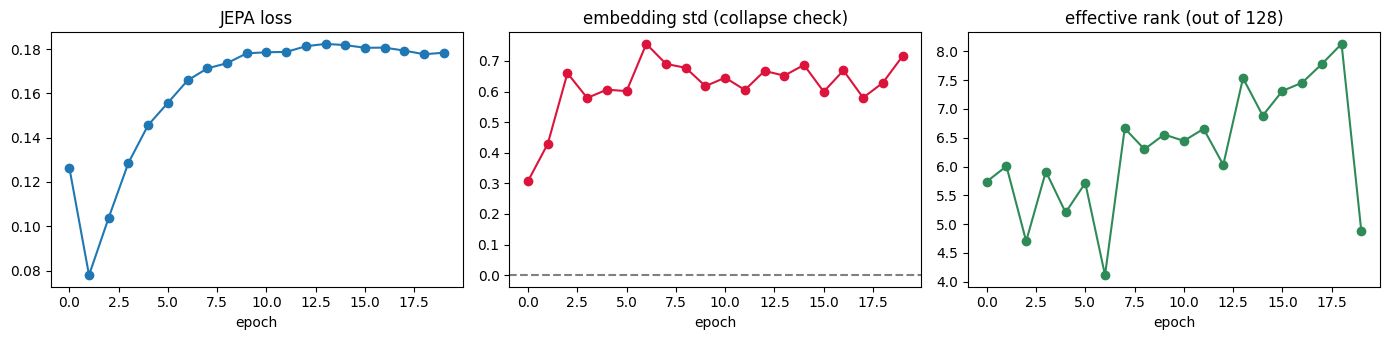

In [48]:
from gjepa.protein.node_jepa import pretrain_node_jepa

scop = load_scop()
logger.info(f"pretraining corpus: {len(scop)} structures, zero labels")

pretrained, history = pretrain_node_jepa(cfg, scop)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
ax[0].plot(history.epoch, history.loss, "o-"); ax[0].set_title("JEPA loss")
ax[1].plot(history.epoch, history.emb_std, "o-", c="crimson")
ax[1].axhline(0, ls="--", c="grey"); ax[1].set_title("embedding std (collapse check)")
ax[2].plot(history.epoch, history.eff_rank, "o-", c="seagreen")
ax[2].set_title(f"effective rank (out of {cfg.dim})")
for a_ in ax:
    a_.set_xlabel("epoch")
plt.tight_layout(); plt.show()

> **Read the third panel carefully.** Effective rank estimates how many dimensions your
> representation is genuinely using. If it says 3 out of 128, you have dimensional collapse
> even though the loss looks perfectly reasonable.
>
> When we ran this ourselves, we got about 3. That is not a typo and it is not a target. It
> is an honest report of where our version of this model ended up, and improving it is one of
> the open problems in Part 9.

## 📖 Fine-tuning on ΔΔG

Now the labels. To predict the effect of mutating residue `i`, the head gets three things:

* the encoder's embedding **at residue i**
* which amino acid **was** there
* which amino acid is there **now**

One trick makes this fast. Every mutation of a given protein shares the same wild-type
structure, so we encode each structure **once** and score all of its ~900 mutations from the
cached embeddings. 215,000 training examples collapse into about 30 forward passes per epoch.

We train **two models**: one starting from your pretrained encoder, one from random weights.
Same architecture, same data, same budget. The gap between them is what pretraining is worth,
and it is the only number in this notebook that actually answers the question we started with.

⚠ `freeze=True` trains only the head and keeps the encoder fixed. That is how ThermoMPNN uses
ProteinMPNN, and in our experiments it is where the pretraining advantage shows up at all.
With full fine-tuning both arms converge to about the same place, because 350 steps of
gradient is enough to overwrite whatever the pretraining put there. Try both. The difference
between those two settings is one of the more interesting findings available to you here.

In [52]:
from gjepa.protein.data import (load_megascale_structures, load_megascale_ddg,
                                attach_node_index)
from gjepa.protein.ddg import train_ddg, evaluate

structures = load_megascale_structures()
ddg = attach_node_index(load_megascale_ddg(), structures)
train = ddg[ddg.split == "train"].reset_index(drop=True)
val   = ddg[ddg.split == "val"].reset_index(drop=True)
test  = ddg[ddg.split == "test"].reset_index(drop=True)

for name, d in [("train", train), ("val", val), ("test", test)]:
    logger.info(f"{name:5s} {len(d):>7,} mutations   {d.WT_name.nunique():>3} proteins")

disjoint = not (set(train.WT_name) & set(test.WT_name))
(logger.success if disjoint else logger.error)(f"protein-disjoint splits: {disjoint}")
logger.warning(f"fraction destabilising: {(train.ddG < 0).mean():.1%}  "
               "a model that always says 'destabilising' is already mostly right")

INFO    | train 215,731 mutations   239 proteins
INFO    | val    27,328 mutations    31 proteins
INFO    | test   28,172 mutations    28 proteins
SUCCESS | protein-disjoint splits: True
WARNING | fraction destabilising: 77.4%  a model that always says 'destabilising' is already mostly right


⚠ That last line deserves a pause. **77% of the measured mutations are destabilising.** Any
metric you report has to survive that imbalance. A model that has learned nothing except
"mutations are usually bad" will still get a respectable-looking correlation.

In [50]:
results = {}
for arm in ["scratch", "pretrained"]:
    torch.manual_seed(0)
    model = NodeJEPA(cfg).to(cfg.device)
    if arm == "pretrained":
        model.encoder.load_state_dict(pretrained.encoder.state_dict())

    head, hist, best = train_ddg(model, structures, train, val, cfg,
                                 epochs=15, lr=1e-3, freeze=True, seed=0)
    results[arm] = evaluate(model, head, structures, test, cfg.device)[0]
    logger.success(f"{arm:11s} test Spearman {results[arm]['spearman']:.4f}")

INFO    |   ep   0  mse 0.8290  val rho 0.5216  per-prot 0.5167  rmse 0.7732
INFO    |   ep   1  mse 0.7288  val rho 0.5453  per-prot 0.5422  rmse 0.7602
INFO    |   ep   2  mse 0.6927  val rho 0.5519  per-prot 0.5512  rmse 0.7578
INFO    |   ep   3  mse 0.6768  val rho 0.5695  per-prot 0.5656  rmse 0.7196
INFO    |   ep   4  mse 0.6803  val rho 0.5825  per-prot 0.5811  rmse 0.7283
INFO    |   ep   5  mse 0.6807  val rho 0.5890  per-prot 0.5837  rmse 0.7486
INFO    |   ep   6  mse 0.6861  val rho 0.5805  per-prot 0.5784  rmse 0.7278
INFO    |   ep   7  mse 0.6590  val rho 0.5814  per-prot 0.5829  rmse 0.7251
INFO    |   ep   8  mse 0.6560  val rho 0.5969  per-prot 0.5888  rmse 0.7144
INFO    |   ep   9  mse 0.6516  val rho 0.5875  per-prot 0.5891  rmse 0.7167
INFO    |   ep  10  mse 0.6420  val rho 0.5956  per-prot 0.5947  rmse 0.7010
INFO    |   ep  11  mse 0.6526  val rho 0.6000  per-prot 0.5971  rmse 0.7001
INFO    |   ep  12  mse 0.6901  val rho 0.5993  per-prot 0.5991  rmse 0.7017

## 📊 The benchmark

Report all three numbers, because they measure different things and they do not always agree:

* **Spearman**: does the model rank mutations correctly overall?
* **per-protein Spearman**: does it rank correctly *within* a single protein? This is closer
  to what a protein engineer actually wants, since they are choosing between mutations of one
  protein.
* **RMSE**: are the predicted numbers the right size, not just the right order?

When they disagree, that is information rather than an annoyance.

In [51]:
import pandas as pd

table = pd.DataFrame(results).T[["spearman", "spearman_per_protein", "rmse"]]
table.loc["ThermoMPNN (scratch)"]    = [0.642, np.nan, 0.789]
table.loc["ThermoMPNN (pretrained)"] = [0.725, np.nan, 0.708]
logger.info(f"\n{table.round(4).to_string()}")

delta = results["pretrained"]["spearman"] - results["scratch"]["spearman"]
logger.success(f"pretraining is worth {delta:+.4f} Spearman, on ONE seed")
logger.warning("Before believing that number: the scratch model alone varies by about 0.02")
logger.warning("between random seeds. One seed cannot distinguish a real effect from noise.")
logger.warning("Run several seeds and report an error bar, or you are reporting nothing.")

INFO    | 
                         spearman  spearman_per_protein    rmse
scratch                    0.5581                0.6027  0.8276
pretrained                 0.5992                0.6275  0.8155
ThermoMPNN (scratch)       0.6420                   NaN  0.7890
ThermoMPNN (pretrained)    0.7250                   NaN  0.7080
SUCCESS | pretraining is worth +0.0411 Spearman, on ONE seed
WARNING | Before believing that number: the scratch model alone varies by about 0.02
WARNING | between random seeds. One seed cannot distinguish a real effect from noise.
WARNING | Run several seeds and report an error bar, or you are reporting nothing.


---
# Part 9: 🔬 Go find something out

Everything above is scaffolding. **This is the project.**

Pick a question. Run it properly. Report what you found, including if what you found is
"no difference", which is a real result and a more useful one than a cherry-picked win.

## Questions we already know are interesting

**A. Frozen or fine-tuned?**
Freeze the encoder and pretraining helps clearly. Fine-tune the whole thing and the advantage
mostly vanishes, because the gradient overwrites what was learned. What learning rate, or
what gradual-unfreezing schedule, keeps the benefit? This is a real open question and the
answer is useful to anyone doing transfer learning.

**B. How much unlabelled data do you actually need?**
Pretrain on 500, 2000, 6782 structures (`load_scop(limit=...)`). Does the benefit grow
steadily, or plateau? Where is the knee in the curve?

**C. Which GNN layer?**
`cfg.conv_type` accepts `GINEConv`, `GCNConv`, `SAGEConv`, `GATv2Conv`, `TransformerConv`.
Remember Demo 2.2: sum counts and mean does not. Remember also that `GCNConv` and `SAGEConv`
**cannot see edge features at all**, so they discard every distance in the structure.
**Predict the ordering before you run it**, then check. Being wrong here is more interesting
than being right.

**D. What should you hide, and how much?**
Contiguous region or scattered residues (`cfg.mask_mode`)? 10%, 25%, 50%, 75%
(`cfg.mask_ratio`)? MAE found 75% best for images. Proteins are not images.

**E. Latent or literal?**
Change the objective to predict the masked residues' *identities* (a 20-way classification)
instead of their representations. That is a masked autoencoder, and it is what Pythia does
for this exact task. Which wins, and on which metric? This is the JEPA-versus-MAE question on
real data, and as far as we can tell nobody has published the comparison.

**F. Is your model just saying "destabilising"?**
77% of the data is destabilising. Evaluate on the stabilising mutations alone. Does your
Spearman survive? Most published models struggle badly here, and it is a known open problem
in the field rather than a flaw in your code.

**G. Better features.**
We use only Cα atoms. Serious models use the full backbone (N, Cα, C, O) and dihedral angles.
That gap is most of why we score around 0.59 and ThermoMPNN scores 0.642. Add backbone
geometry and see how much you close.

## How to report anything

For every claim you make:

* **several seeds**, with an error bar. Not one run.
* the **random-initialisation control**, every time.
* say which metric you are quoting, and do not switch metrics between experiments.
* if your confidence interval crosses zero, say so plainly.

The most valuable thing you can produce this week is a result you believe for good reasons.
Good luck.

In [53]:
import numpy as np

seeds = [0, 1, 2]
exp_a_results = {"scratch": [], "pretrained": []}

for seed in seeds:
    for arm in ["scratch", "pretrained"]:
        torch.manual_seed(seed)
        model = NodeJEPA(cfg).to(cfg.device)
        if arm == "pretrained":
            model.encoder.load_state_dict(pretrained.encoder.state_dict())

        head, hist, best = train_ddg(
            model, structures, train, val, cfg,
            epochs=10, lr=1e-3, freeze=True, seed=seed
        )
        spearman = evaluate(model, head, structures, test, cfg.device)[0]["spearman"]
        exp_a_results[arm].append(spearman)
        logger.info(f"seed {seed} | {arm:11s} | spearman {spearman:.4f}")

for arm in ["scratch", "pretrained"]:
    scores = exp_a_results[arm]
    logger.success(f"{arm:11s} | mean {np.mean(scores):.4f} ± {np.std(scores):.4f}")

delta = np.mean(exp_a_results["pretrained"]) - np.mean(exp_a_results["scratch"])
logger.success(f"pretraining effect: {delta:+.4f} Spearman over {len(seeds)} seeds")

INFO    |   ep   0  mse 0.8290  val rho 0.5216  per-prot 0.5167  rmse 0.7732
INFO    |   ep   1  mse 0.7288  val rho 0.5453  per-prot 0.5422  rmse 0.7602
INFO    |   ep   2  mse 0.6927  val rho 0.5519  per-prot 0.5512  rmse 0.7578
INFO    |   ep   3  mse 0.6768  val rho 0.5695  per-prot 0.5656  rmse 0.7196
INFO    |   ep   4  mse 0.6803  val rho 0.5825  per-prot 0.5811  rmse 0.7283
INFO    |   ep   5  mse 0.6807  val rho 0.5890  per-prot 0.5837  rmse 0.7486
INFO    |   ep   6  mse 0.6861  val rho 0.5805  per-prot 0.5784  rmse 0.7278
INFO    |   ep   7  mse 0.6590  val rho 0.5814  per-prot 0.5829  rmse 0.7251
INFO    |   ep   8  mse 0.6560  val rho 0.5969  per-prot 0.5888  rmse 0.7144
INFO    |   ep   9  mse 0.6516  val rho 0.5875  per-prot 0.5891  rmse 0.7167
INFO    | seed 0 | scratch     | spearman 0.5496
INFO    |   ep   0  mse 0.8425  val rho 0.5626  per-prot 0.5461  rmse 0.7521
INFO    |   ep   1  mse 0.6800  val rho 0.5985  per-prot 0.5847  rmse 0.7061
INFO    |   ep   2  mse 0.6